In [8]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS, poly
from functools import partial

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
(sklearn_sm, Stepwise,
sklearn_selected,
sklearn_selection_path)
from l0bnb import fit_path

In [18]:
wage = load_data("Wage")
wage.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


Perform polynomial regression to predict wage using age. Use
cross-validation to select the optimal degree d for the polynomial. What degree was chosen, and how does this compare to
the results of hypothesis testing using ANOVA? Make a plot of
the resulting polynomial fit to the data.

In [ ]:
def perform_poly_regression(train, degree=1):
    ms = MS([poly("age", degree=degree)])
    design = ms.fit(train)
    X = design.transform(train)
    y = np.array(train["wage"])

    model = sm.OLS(y,X)
    result = model.fit()

    return result, design

In [20]:
M = sklearn_sm(sm.OLS)
def perform_cross_validation(dataset, degree=1):
    ms = MS([poly("age", degree=degree)])
    design = ms.fit(dataset)
    X = design.transform(dataset)
    y = np.array(dataset["wage"])

    model = sm.OLS(y,X)
    result = model.fit()
    m_cv = skm.cross_validate(M, X, y, cv=dataset.shape[0])

    return m_cv


In [24]:
N = 20
cv_scores = []
for i in range(1, N):
    cv = perform_cross_validation(wage, degree=i)["test_score"]
    cv_scores.append((cv.mean(), cv.std()))

    print(f"Poly: {i}, Scores: {cv_scores[-1]}")

Poly: 1, Scores: (np.float64(1676.2348845876563), np.float64(4425.2932039323605))
Poly: 2, Scores: (np.float64(1600.5292729229639), np.float64(4309.211803778271))
Poly: 3, Scores: (np.float64(1595.9595683998562), np.float64(4305.756404518192))
Poly: 4, Scores: (np.float64(1594.5958669712527), np.float64(4301.242868620686))
Poly: 5, Scores: (np.float64(1594.878561336701), np.float64(4297.3823520027645))
Poly: 6, Scores: (np.float64(1594.118896030374), np.float64(4290.539818481615))
Poly: 7, Scores: (np.float64(1594.145448319432), np.float64(4284.416823906822))
Poly: 8, Scores: (np.float64(1594.974872203588), np.float64(4285.336614766869))
Poly: 9, Scores: (np.float64(1593.3563311047858), np.float64(4279.790325341483))
Poly: 10, Scores: (np.float64(1594.232455299621), np.float64(4281.875183721953))
Poly: 11, Scores: (np.float64(1595.064250339377), np.float64(4284.549357391097))
Poly: 12, Scores: (np.float64(1595.8589712299122), np.float64(4286.397612412313))
Poly: 13, Scores: (np.float64

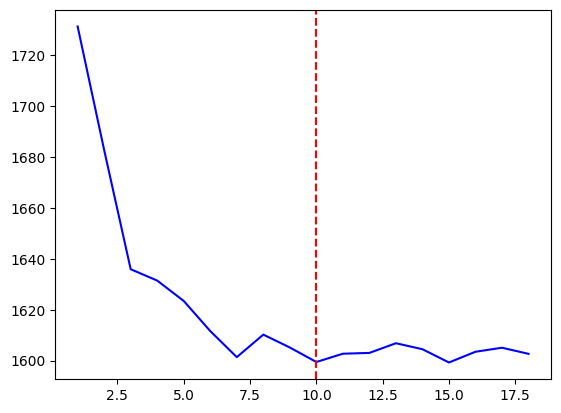

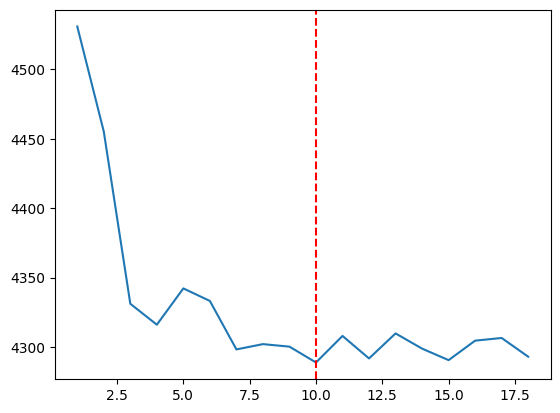

In [40]:
# Plotting the cv scores
import matplotlib.pyplot as plt 

plt.plot(range(1,19), [mean for mean,_ in cv_scores], color="blue")
plt.axvline(x=10, color="red", linestyle="--")
# plt.plot(range(19), [std for _,std in cv_scores])
plt.show()

plt.plot(range(1,19), [std for _,std in cv_scores])
plt.axvline(x=10, color="red", linestyle="--")
plt.show()

=> the optimum number of degrees seems to be 10, having the lowest standard deviation and the lowest mean error.

In [35]:
from sklearn.preprocessing import KBinsDiscretizer

def perform_step_function_cv(dataset, n_cuts=4):
    # Prepare X and y
    X = dataset[["age"]].values
    y = np.array(dataset["wage"])
    
    kbin = KBinsDiscretizer(n_bins=n_cuts, encode='onehot-dense', strategy='uniform')
    X_binned = kbin.fit_transform(X)
    
    model = sm.OLS(y, X_binned)
    result = model.fit()
    
    M = sklearn_sm(sm.OLS)
    cv_scores = skm.cross_validate(M, X_binned, y, cv=dataset.shape[0], scoring='neg_mean_squared_error')
    
    mean = -cv_scores["test_score"].mean()
    std = cv_scores["test_score"].std()
    
    return mean, std

In [36]:
N = 20
cv_scores = []
for i in range(2, N):
    cv = perform_step_function_cv(wage, n_cuts=i)
    cv_scores.append((cv[0], cv[1]))

    print(f"Poly: {i}, Scores: {cv_scores[-1]}")

Poly: 2, Scores: (np.float64(1731.3390663774871), np.float64(4530.795689150217))
Poly: 3, Scores: (np.float64(1682.7631242558007), np.float64(4455.100610849375))
Poly: 4, Scores: (np.float64(1635.9174201242367), np.float64(4331.121105058951))
Poly: 5, Scores: (np.float64(1631.4497370009528), np.float64(4316.04285374767))
Poly: 6, Scores: (np.float64(1623.4377347651186), np.float64(4342.186095161785))
Poly: 7, Scores: (np.float64(1611.6042758165695), np.float64(4333.151693131675))
Poly: 8, Scores: (np.float64(1601.3538624356836), np.float64(4298.249371033219))
Poly: 9, Scores: (np.float64(1610.2128195834955), np.float64(4302.05559346165))
Poly: 10, Scores: (np.float64(1605.1457353563574), np.float64(4300.243768260144))
Poly: 11, Scores: (np.float64(1599.4443759437258), np.float64(4288.844803326001))
Poly: 12, Scores: (np.float64(1602.6984312020686), np.float64(4307.9561709806))
Poly: 13, Scores: (np.float64(1603.016656817307), np.float64(4291.741380570255))
Poly: 14, Scores: (np.float64

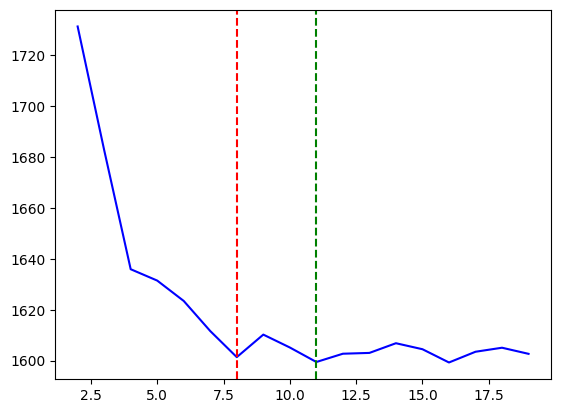

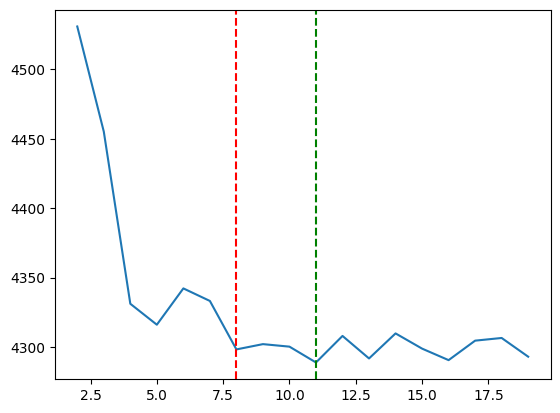

In [42]:
# Plotting the cv scores
import matplotlib.pyplot as plt 

plt.plot(range(2,20), [mean for mean,_ in cv_scores], color="blue")
plt.axvline(x=8, color="red", linestyle="--")
plt.axvline(x=11, color="green", linestyle="--")
# plt.plot(range(19), [std for _,std in cv_scores])
plt.show()

plt.plot(range(2,20), [std for _,std in cv_scores])
plt.axvline(x=8, color="red", linestyle="--")
plt.axvline(x=11, color="green", linestyle="--")
plt.show()

=> The optimum number of cuts seems to be 8 or 11